# Artificial Intelligence and Application Midterm Exam

Konrad Wojda, 9307820244

## Task 1

To load and process data I will use pandas library and for drawing graph I will use pyplot from matplotlib.

In [108]:
import pandas as pd
import matplotlib.pyplot as plt

Firstly, let's load data and convert datetime strings to datetime.

In [109]:
data_frame = pd.read_csv('data/2024-03-transaction.csv')

data_frame['timestamp'] = pd.to_datetime(data_frame['timestamp'])

Next, let's filter data from 2024-03-11 to 2024-03-19 and extract hour from each timestamp.

In [110]:
start_date = '2024-03-11'
end_date = '2024-03-19'
data_frame = data_frame[(data_frame['timestamp'] >= start_date) & (data_frame['timestamp'] < end_date)]

data_frame['hour'] = data_frame['timestamp'].dt.floor('h')

Finally, use groupby on hour and side to aggregate number of transactions during each hour.

In [111]:
transaction_counts = data_frame.groupby(['hour', 'side']).size().unstack(fill_value=0)
transaction_counts.columns = ['buy', 'sell']

Now, let's create plot with output data.

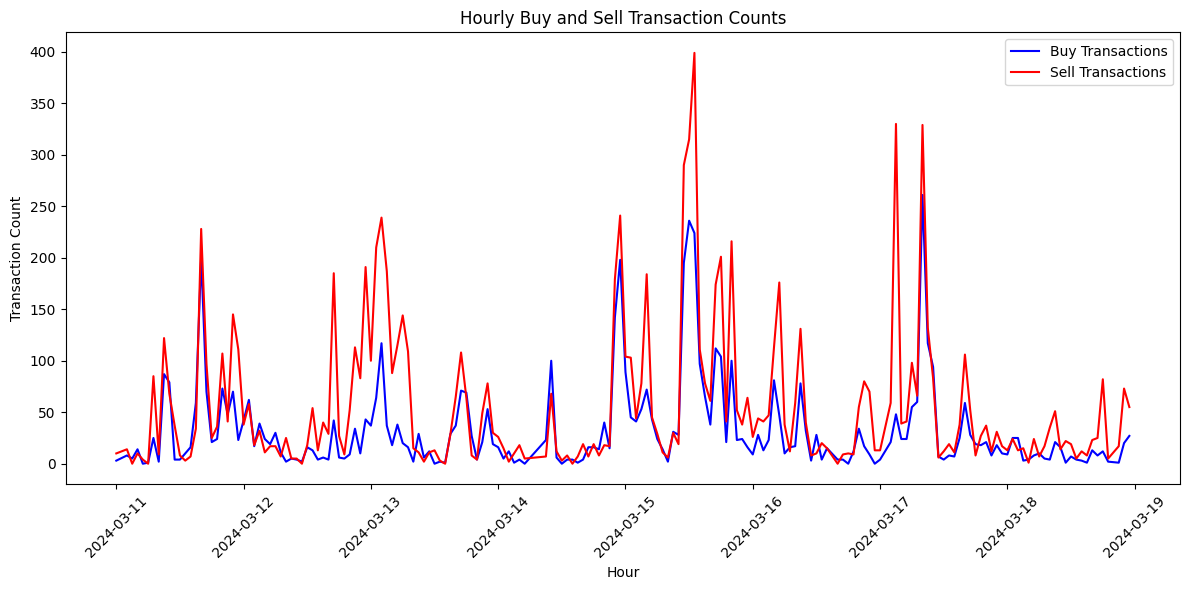

In [112]:
plt.figure(figsize=(12, 6))
plt.plot(transaction_counts.index, transaction_counts['buy'], label='Buy Transactions', color='blue')
plt.plot(transaction_counts.index, transaction_counts['sell'], label='Sell Transactions', color='red')

plt.xlabel('Hour')
plt.ylabel('Transaction Count')
plt.title('Hourly Buy and Sell Transaction Counts')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## Task 2

In [113]:
transactions = pd.read_csv('data/2024-03-11-transaction.csv')
raw_data = pd.read_csv('data/2024-03-11-rawdata.csv')

In [114]:
transactions['timestamp'] = pd.to_datetime(transactions['timestamp'], format='%Y-%m-%d %H:%M')
raw_data['timestamp'] = pd.to_datetime(raw_data['timestamp'], format='%Y-%m-%d %H:%M:%S.%f').dt.floor('s')

In [115]:
raw_data = raw_data[raw_data['timestamp'].dt.second == 0]

In [116]:
grouped_raw_data = raw_data.groupby('timestamp')

In [117]:
def calculate_features(orderbook_slice):
    top_bid_price = orderbook_slice[orderbook_slice['type'] == 0]['price'].iloc[0]
    top_ask_price = orderbook_slice[orderbook_slice['type'] == 1]['price'].iloc[0]
    midprice = (top_ask_price + top_bid_price) * 0.5

    askQty = orderbook_slice[orderbook_slice['type'] == 1]['quantity'].max()
    bidQty = orderbook_slice[orderbook_slice['type'] == 0]['quantity'].max()
    bidPx = orderbook_slice[orderbook_slice['type'] == 0]['price'].mean()

    bookfeature = (askQty * bidPx) / bidQty
    alphaprice = bookfeature - midprice

    return pd.Series([midprice, bookfeature, alphaprice], index=['midprice', 'bookfeature', 'alphaprice'])


In [120]:
features = grouped_raw_data.apply(calculate_features).reset_index()

transactions = pd.merge(transactions, features, left_on='timestamp', right_on='timestamp', how='left')

transactions = transactions[['midprice', 'bookfeature', 'alphaprice', 'timestamp', 'quantity', 'price', 'side']]

result = pd.concat([transactions.head(10), transactions.tail(10)])
print(result)

output_file = 'data/2024-03-11-transaction-modified.csv'
transactions.to_csv(output_file, index=False)


         midprice   bookfeature    alphaprice           timestamp  quantity  \
0      97798500.0  2.628835e+07 -7.151015e+07 2024-03-11 00:07:00  0.150000   
1      97798500.0  2.628835e+07 -7.151015e+07 2024-03-11 00:07:00  0.010229   
2      97798500.0  2.628835e+07 -7.151015e+07 2024-03-11 00:07:00  0.001024   
3      97784500.0  4.044031e+07 -5.734419e+07 2024-03-11 00:11:00  0.052561   
4      97597000.0  2.048226e+08  1.072256e+08 2024-03-11 00:17:00  0.039159   
5      97597000.0  2.048226e+08  1.072256e+08 2024-03-11 00:17:00  0.070000   
6      97597000.0  2.048226e+08  1.072256e+08 2024-03-11 00:17:00  0.037624   
7      97597000.0  2.048226e+08  1.072256e+08 2024-03-11 00:17:00  0.002864   
8      97597000.0  2.048226e+08  1.072256e+08 2024-03-11 00:17:00  0.001092   
9      97849000.0  1.374677e+07 -8.410223e+07 2024-03-11 00:34:00  0.001248   
2037  101286000.0  1.052174e+09  9.508882e+08 2024-03-11 23:31:00  0.004640   
2038  101286000.0  1.052174e+09  9.508882e+08 2024-0

/tmp/ipykernel_4069/4084426493.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  features = grouped_raw_data.apply(calculate_features).reset_index()


## Task 3


Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.79      0.78       259
           1       0.84      0.84      0.84       356

    accuracy                           0.82       615
   macro avg       0.81      0.81      0.81       615
weighted avg       0.82      0.82      0.82       615



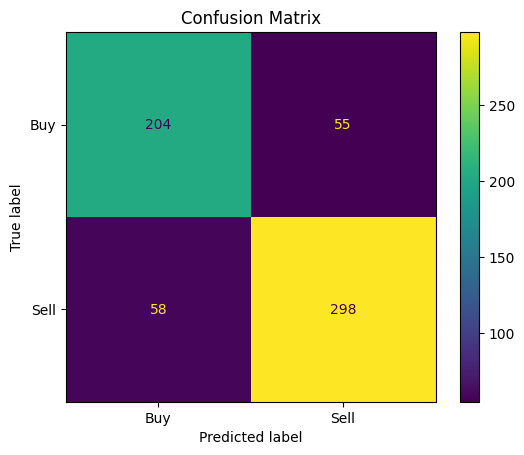

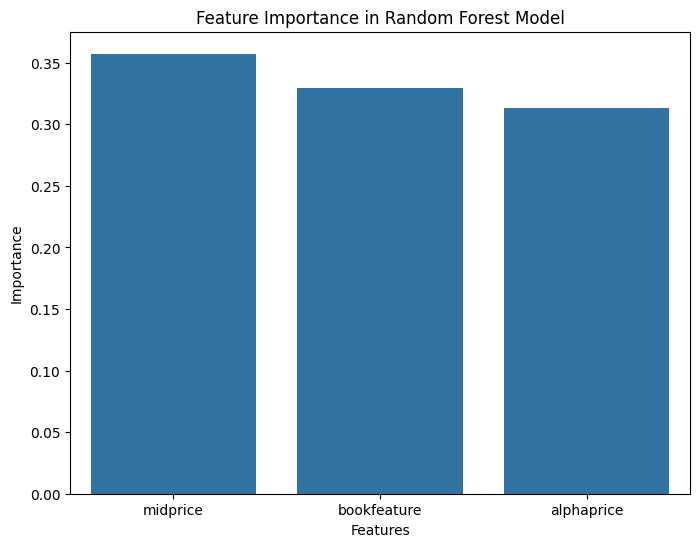

In [147]:
# Imports
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import seaborn as sns

# Load and preprocess data
data_frame = pd.read_csv('data/2024-03-11-transaction-modified.csv')

# Select features and target
X = data_frame[['midprice', 'bookfeature', 'alphaprice']]
X = StandardScaler().fit_transform(X)
Y = data_frame['side']

# Split data
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=101)

# Train the model
model = RandomForestClassifier(n_estimators=700, random_state=101)
model.fit(X_train, Y_train)

# Make predictions
Y_pred = model.predict(X_test)

# Evaluate the model
print("\nClassification Report:")
print(classification_report(Y_test, Y_pred))

# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(model, X_test, Y_test, display_labels=['Buy', 'Sell'])
plt.title("Confusion Matrix")
plt.show()

# Feature Importance
importance = model.feature_importances_
plt.figure(figsize=(8, 6))
sns.barplot(x=['midprice', 'bookfeature', 'alphaprice'], y=importance)
plt.title('Feature Importance in Random Forest Model')
plt.ylabel('Importance')
plt.xlabel('Features')
plt.show()